In [2]:
import pandas as pd 
df = pd.read_csv("drug.csv")


In [3]:
df


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,F,HIGH,HIGH,25.355,DrugY
1,47,M,LOW,HIGH,13.093,drugC
2,47,M,LOW,HIGH,10.114,drugC
3,28,F,NORMAL,HIGH,7.798,drugX
4,61,F,LOW,HIGH,18.043,DrugY
...,...,...,...,...,...,...
195,56,F,LOW,HIGH,11.567,drugC
196,16,M,LOW,HIGH,12.006,drugC
197,52,M,NORMAL,HIGH,9.894,drugX
198,23,M,NORMAL,NORMAL,14.020,drugX


In [4]:
import numpy as np
import seaborn as sns

import matplotlib.pyplot as plt


In [5]:
df.isna().sum()


Age            0
Sex            0
BP             0
Cholesterol    0
Na_to_K        0
Drug           0
dtype: int64

In [6]:
df.duplicated()


0      False
1      False
2      False
3      False
4      False
       ...  
195    False
196    False
197    False
198    False
199    False
Length: 200, dtype: bool

In [7]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Age          200 non-null    int64  
 1   Sex          200 non-null    str    
 2   BP           200 non-null    str    
 3   Cholesterol  200 non-null    str    
 4   Na_to_K      200 non-null    float64
 5   Drug         200 non-null    str    
dtypes: float64(1), int64(1), str(4)
memory usage: 9.5 KB


In [8]:
x = df.Sex.value_counts()

print(x)


Sex
M    104
F     96
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

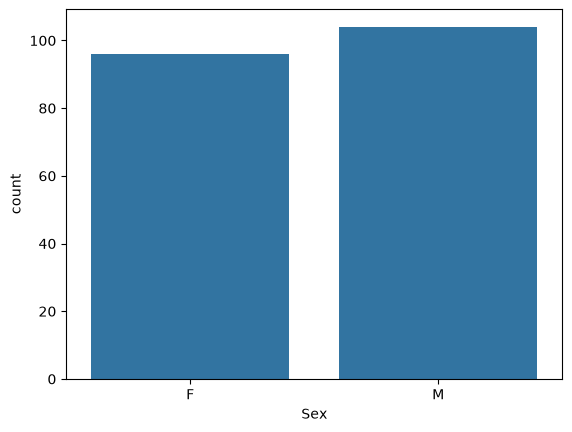

In [9]:
p=sns.countplot(data=df,x="Sex")

plt.show


Drug
DrugY    91
drugX    54
drugA    23
drugC    16
drugB    16
Name: count, dtype: int64


<function matplotlib.pyplot.show(close=None, block=None)>

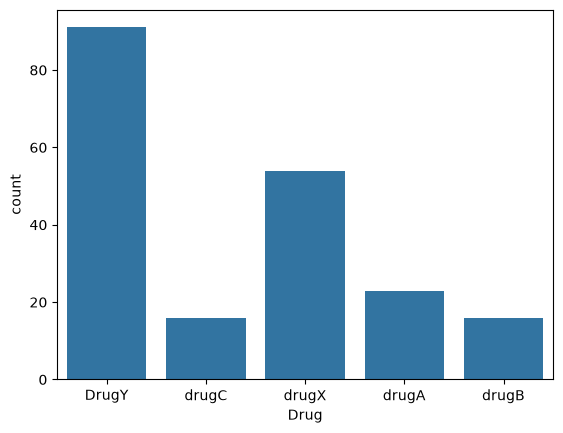

In [10]:
x = df.Drug.value_counts()

print(x)

p = sns.countplot(data=df, x="Drug")

plt.show


In [11]:
df["Drug"].unique()


<StringArray>
['DrugY', 'drugC', 'drugX', 'drugA', 'drugB']
Length: 5, dtype: str

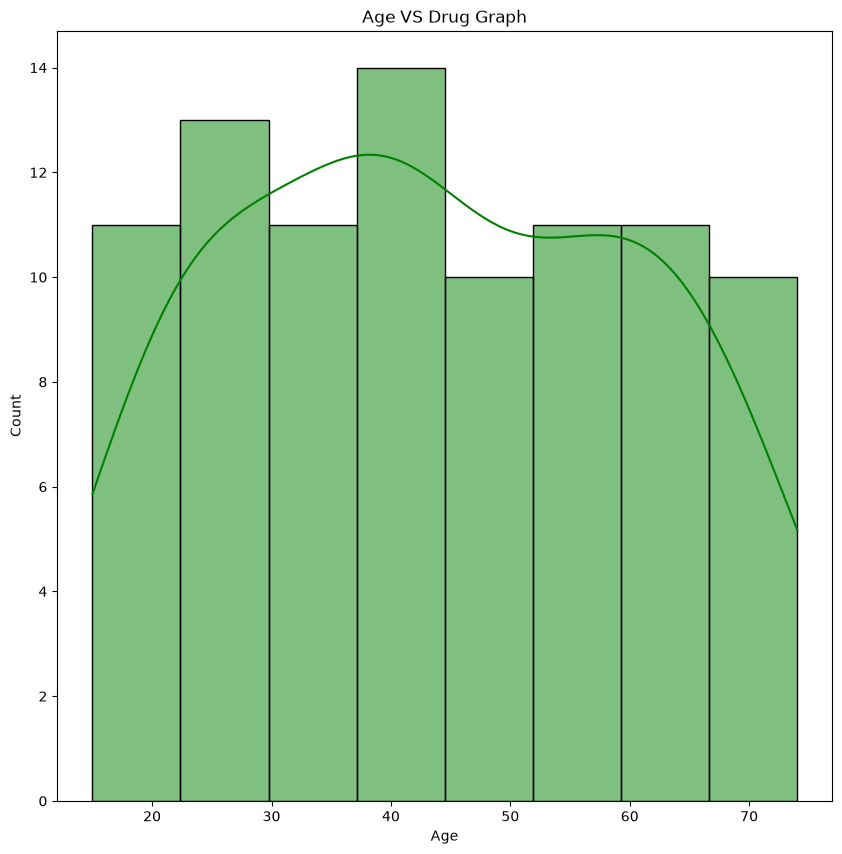

In [14]:
plt.figure(figsize=(10,10))

# 2. Use axes-level functions (histplot) with a label for the legend
sns.histplot(df[df["Drug"] == "DrugY"]["Age"], color="green", label="DrugY", kde=True)
sns.histplot(df[df["Drug"] == "DrugX"]["Age"], color="red", label="DrugX", kde=True)
sns.histplot(df[df["Drug"] == "DrugA"]["Age"], color="black", label="DrugA", kde=True)
sns.histplot(df[df["Drug"] == "DrugB"]["Age"], color="orange", label="DrugB", kde=True)
sns.histplot(df[df["Drug"] == "DrugC"]["Age"], color="blue", label="DrugC", kde=True)


plt.title("Age VS Drug Graph")


plt.show()


In [15]:
from sklearn.preprocessing import OrdinalEncoder

oe = OrdinalEncoder()

df['BP']=oe.fit_transform(df[['BP']])
df["Sex"] = oe.fit_transform(df[["Sex"]])
df["Cholesterol"] = oe.fit_transform(df[["Cholesterol"]])
df["Drug"] = oe.fit_transform(df[["Drug"]])


In [ ]:
df


,Age,Sex,BP,Cholesterol,Na_to_K,Drug
0,23,0.0,0.0,0.0,25.355,0.0
1,47,1.0,1.0,0.0,13.093,3.0
2,47,1.0,1.0,0.0,10.114,3.0
3,28,0.0,2.0,0.0,7.798,4.0
4,61,0.0,1.0,0.0,18.043,0.0
...,...,...,...,...,...,...
195,56,0.0,1.0,0.0,11.567,3.0
196,16,1.0,1.0,0.0,12.006,3.0
197,52,1.0,2.0,0.0,9.894,4.0
198,23,1.0,2.0,1.0,14.020,4.0


In [ ]:
X = df.iloc[:, 0:-1]
y = df.iloc[:, -1]


In [ ]:
X


,Age,Sex,BP,Cholesterol,Na_to_K
0,23,0.0,0.0,0.0,25.355
1,47,1.0,1.0,0.0,13.093
2,47,1.0,1.0,0.0,10.114
3,28,0.0,2.0,0.0,7.798
4,61,0.0,1.0,0.0,18.043
...,...,...,...,...,...
195,56,0.0,1.0,0.0,11.567
196,16,1.0,1.0,0.0,12.006
197,52,1.0,2.0,0.0,9.894
198,23,1.0,2.0,1.0,14.020


In [ ]:
y


0      0.0
1      3.0
2      3.0
3      4.0
4      0.0
      ... 
195    3.0
196    3.0
197    4.0
198    4.0
199    4.0
Name: Drug, Length: 200, dtype: float64

In [20]:
from sklearn.model_selection import train_test_split
X_train,X_test , y_train,y_test = train_test_split(X,y,random_state=42,test_size=0.2)


In [21]:
X_train


,Age,Sex,BP,Cholesterol,Na_to_K
79,32,0.0,1.0,1.0,10.840
197,52,1.0,2.0,0.0,9.894
38,39,0.0,2.0,1.0,9.709
24,33,0.0,1.0,0.0,33.486
122,34,1.0,2.0,0.0,22.456
...,...,...,...,...,...
106,22,1.0,2.0,0.0,11.953
14,50,0.0,2.0,0.0,12.703
92,29,0.0,0.0,0.0,29.450
179,67,0.0,2.0,0.0,15.891


In [22]:
y_train


79     4.0
197    4.0
38     4.0
24     0.0
122    0.0
      ... 
106    4.0
14     4.0
92     0.0
179    0.0
102    3.0
Name: Drug, Length: 160, dtype: float64

In [23]:
from sklearn.tree import DecisionTreeClassifier
clf_gini = DecisionTreeClassifier(criterion='gini',random_state=0)

clf_gini.fit(X_train,y_train)

y_pred_gini = clf_gini.predict(X_test)


In [24]:
y_pred_gini


array([4., 0., 4., 3., 0., 0., 0., 4., 1., 4., 1., 4., 0., 1., 2., 0., 2.,
       4., 3., 0., 2., 4., 4., 0., 0., 0., 3., 4., 0., 4., 0., 3., 3., 0.,
       1., 0., 4., 1., 0., 1.])

In [25]:
from sklearn.metrics import accuracy_score

print(accuracy_score(y_pred_gini,y_test))


1.0


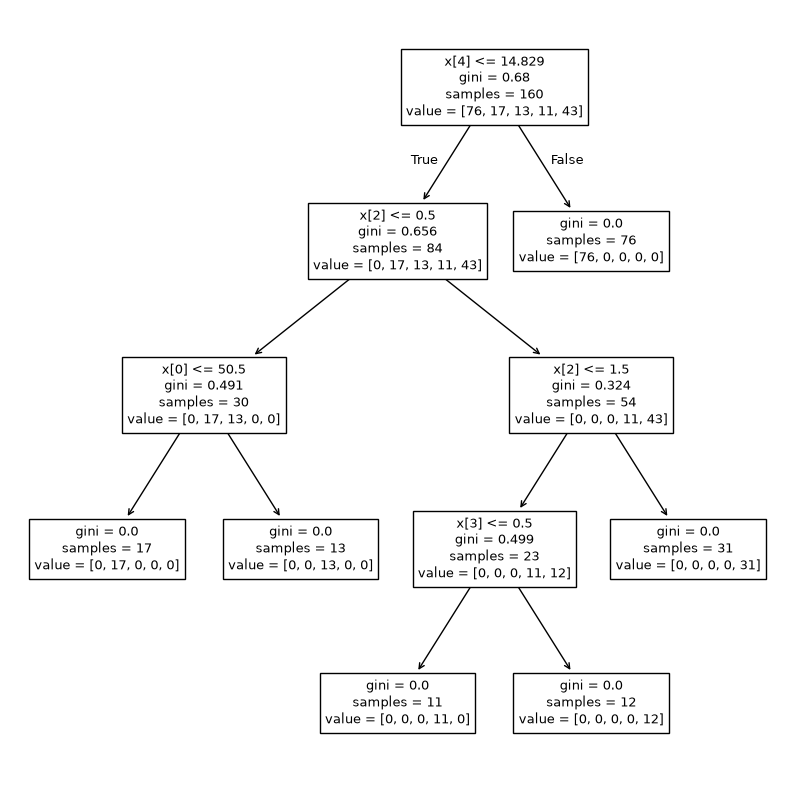

In [26]:
from sklearn import tree

plt.figure(figsize=(10,10))


tree.plot_tree(clf_gini.fit(X_train,y_train))

plt.show()


1.0


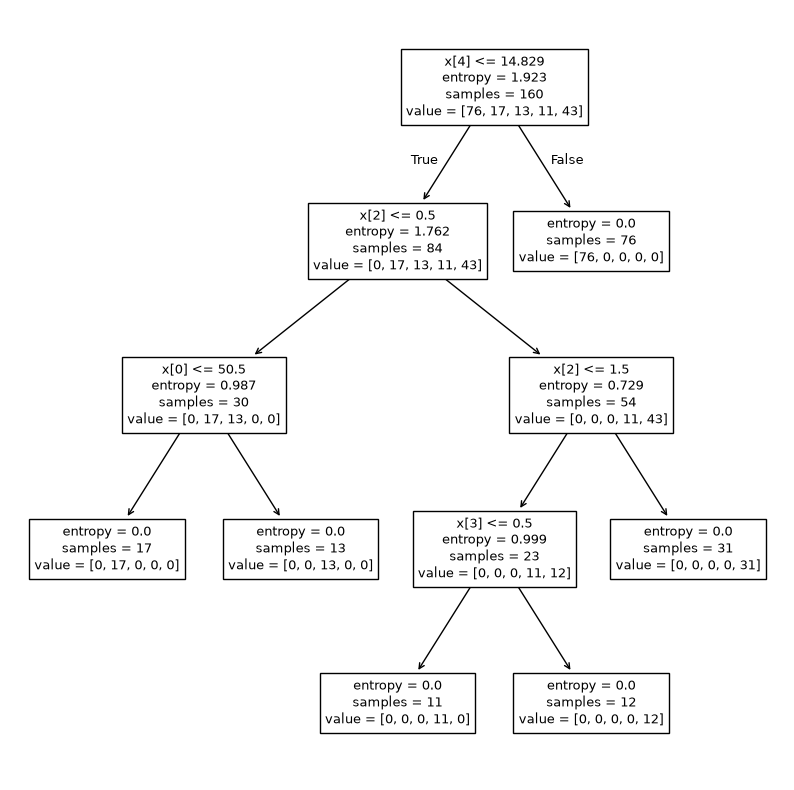

In [30]:
clf_entropy = DecisionTreeClassifier(criterion="entropy",max_depth=4 ,random_state=0,)

clf_entropy.fit(X_train, y_train)

y_pred_entropy = clf_entropy.predict(X_test)

print(accuracy_score(y_pred_entropy, y_test))


plt.figure(figsize=(10, 10))


tree.plot_tree(clf_entropy.fit(X_train, y_train))

plt.show()
